==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


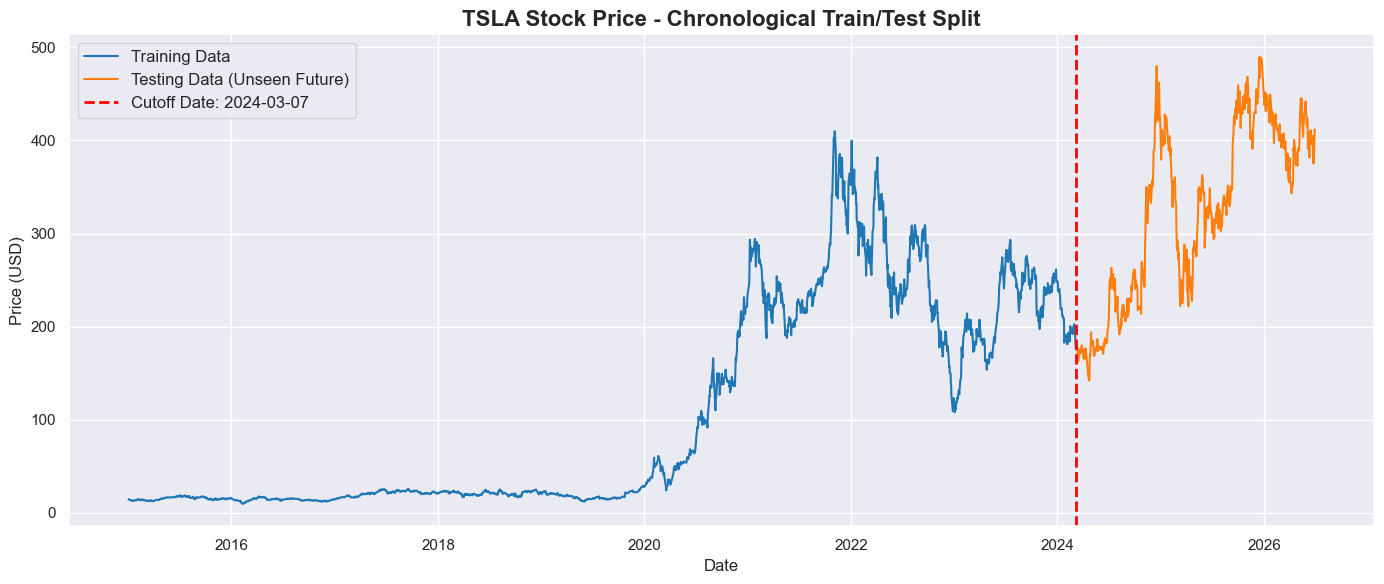

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


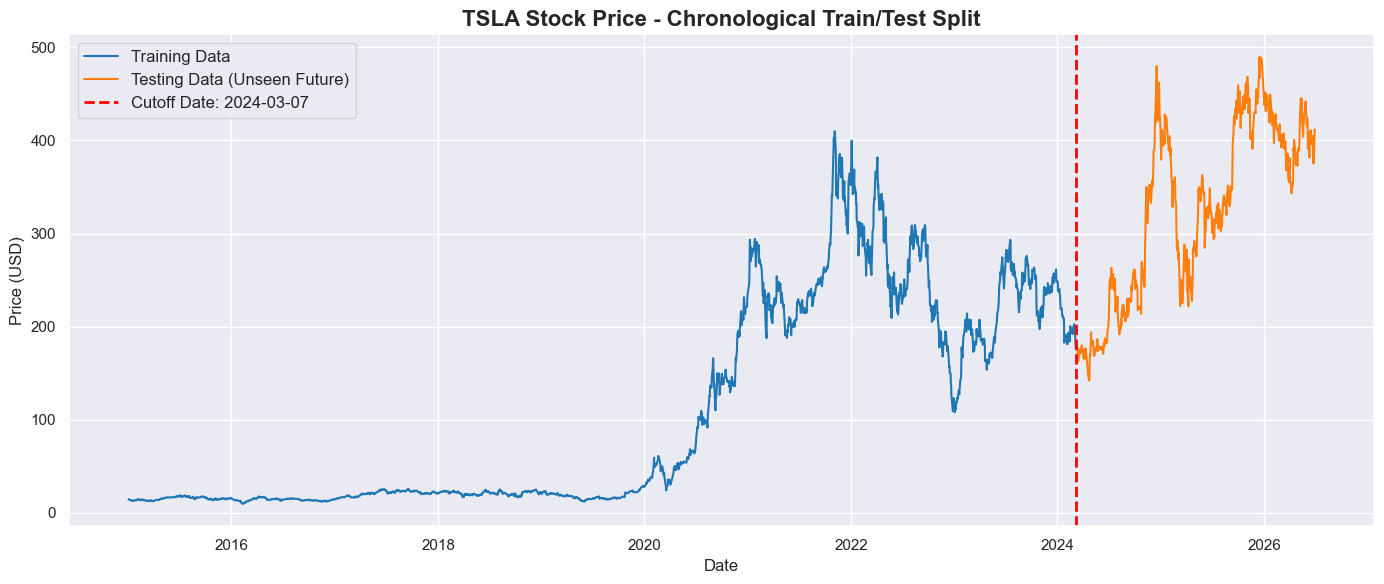


==== ARIMA MODELING: ACF & PACF PLOTS ====


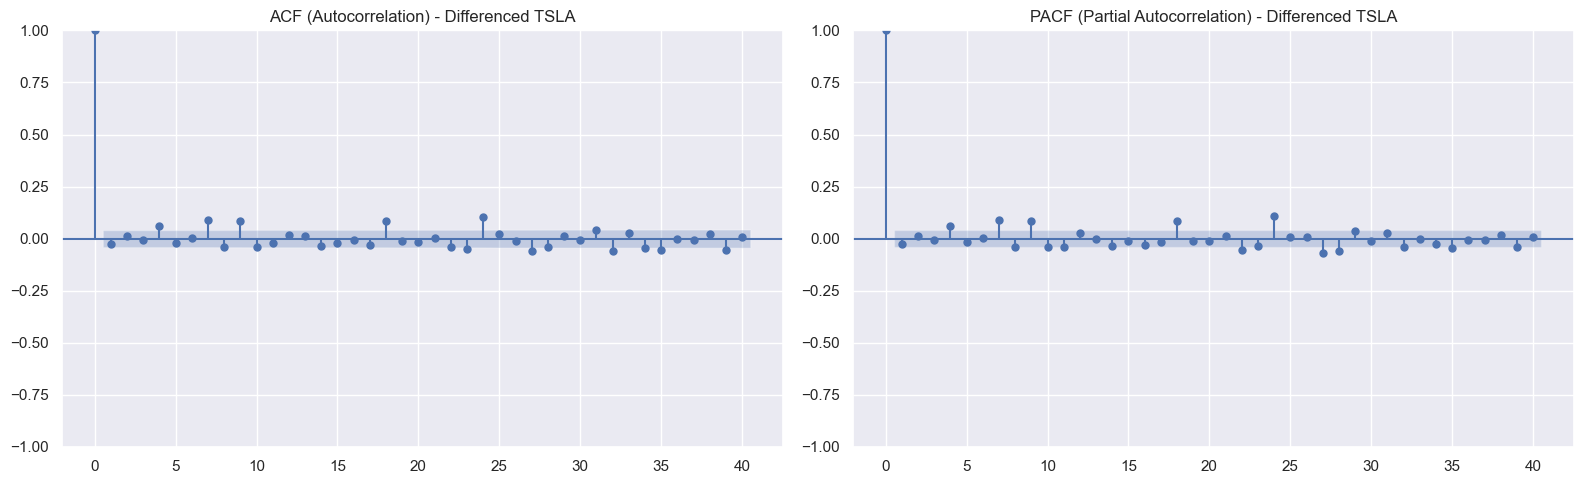


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.32 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.61 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.954 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        00:07:53   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


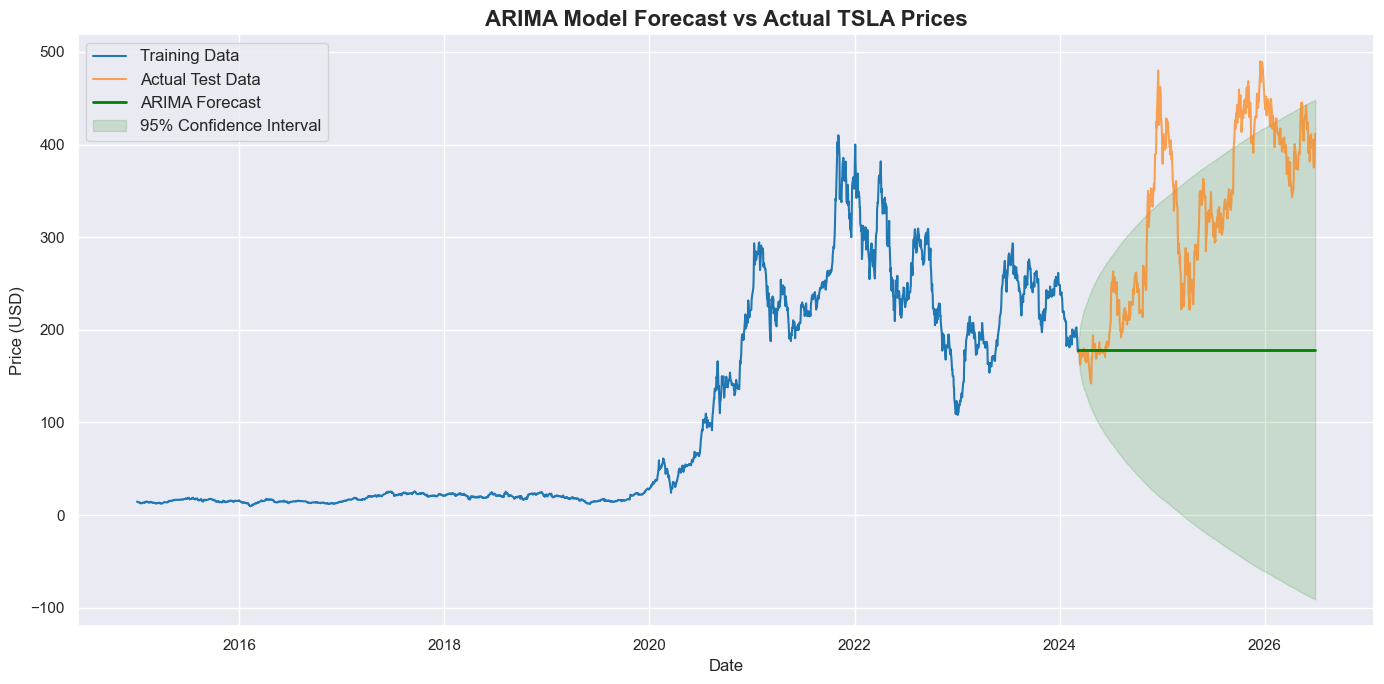

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Uses a smart search algorithm to save time
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title(f'ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


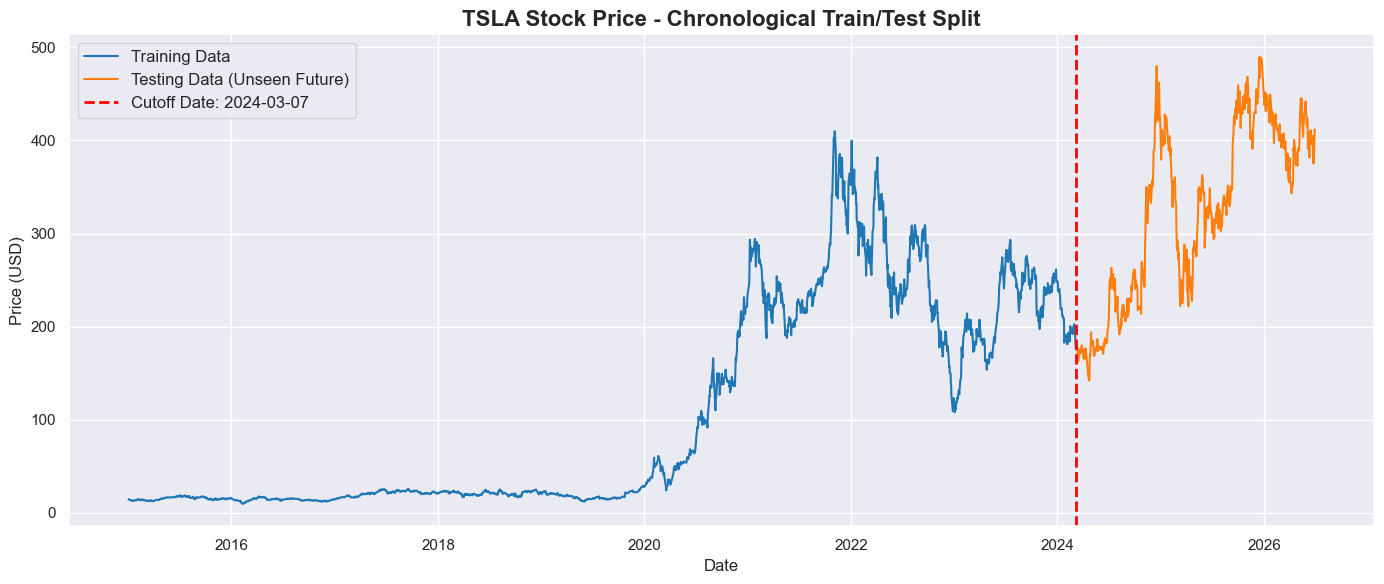


==== ARIMA MODELING: ACF & PACF PLOTS ====


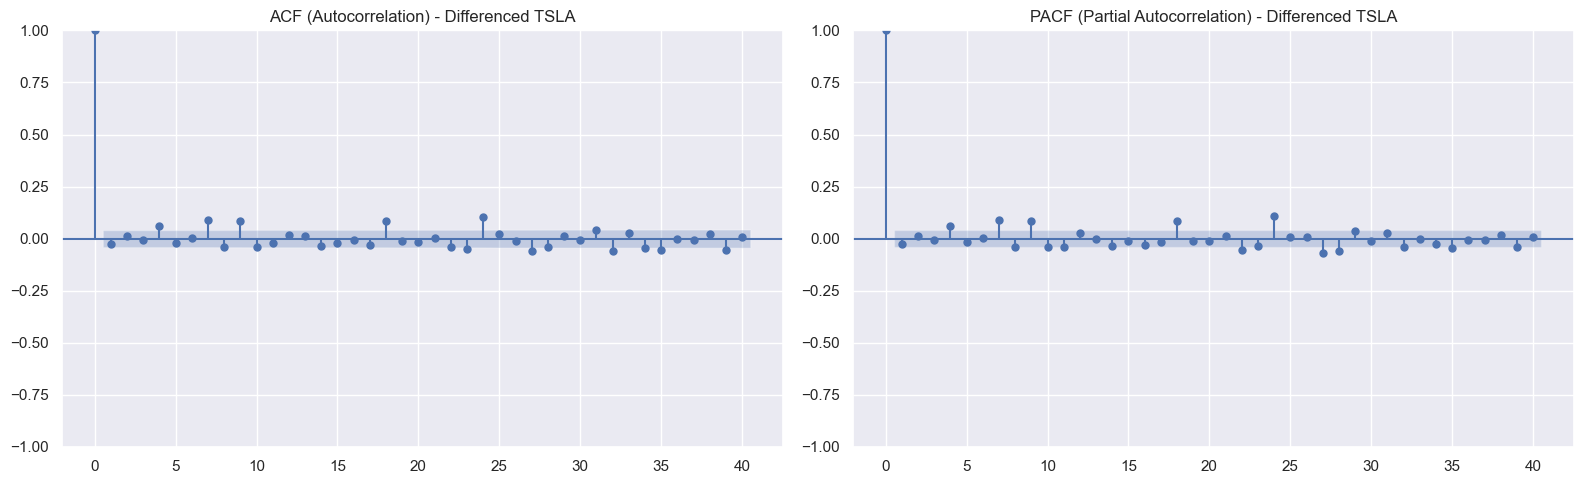


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.22 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.897 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        00:10:26   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


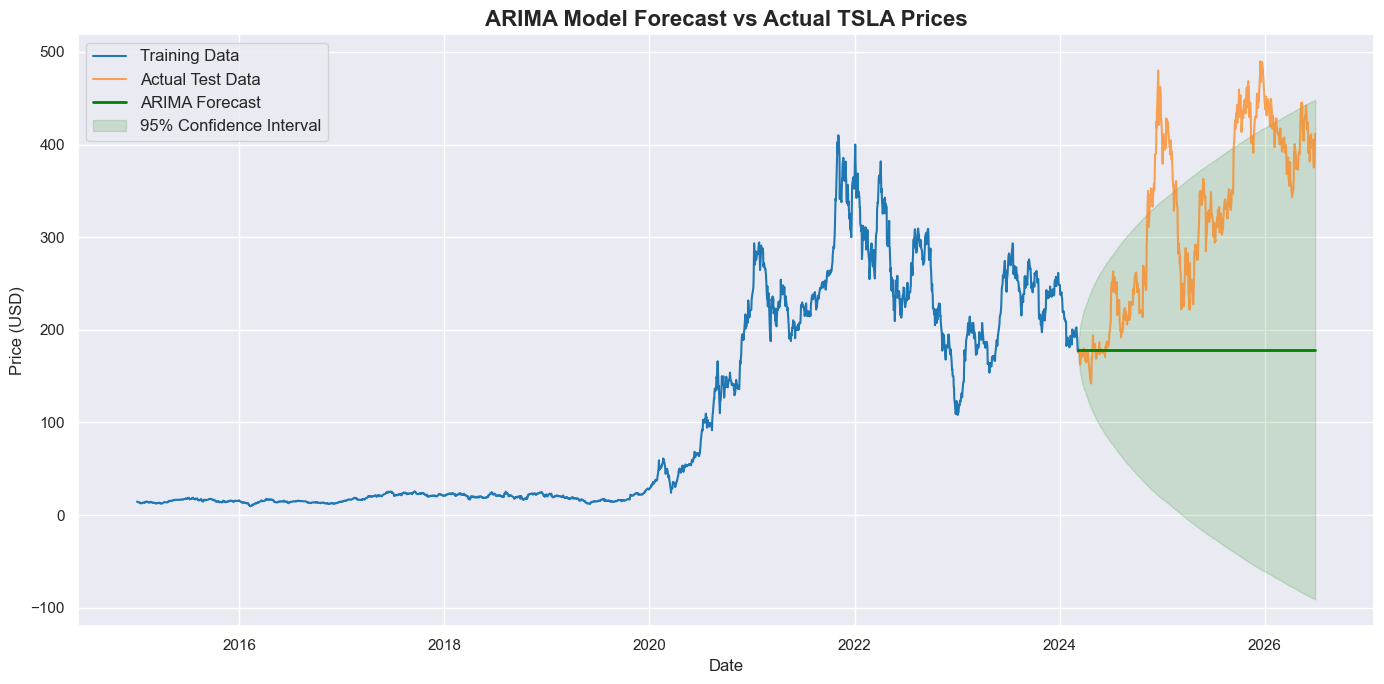


==== RUNNING LSTM MODEL ====


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Training LSTM network (this may take a moment depending on your CPU/GPU)...
Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0173
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.6534e-04
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 5.5511e-04
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 4.9694e-04
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.4288e-04
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 4.0781e-04
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 3.5787e-04
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 4.5237e-04
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 3.2485e-04
Epoch 10/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 3.5248e-04
Generating test predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


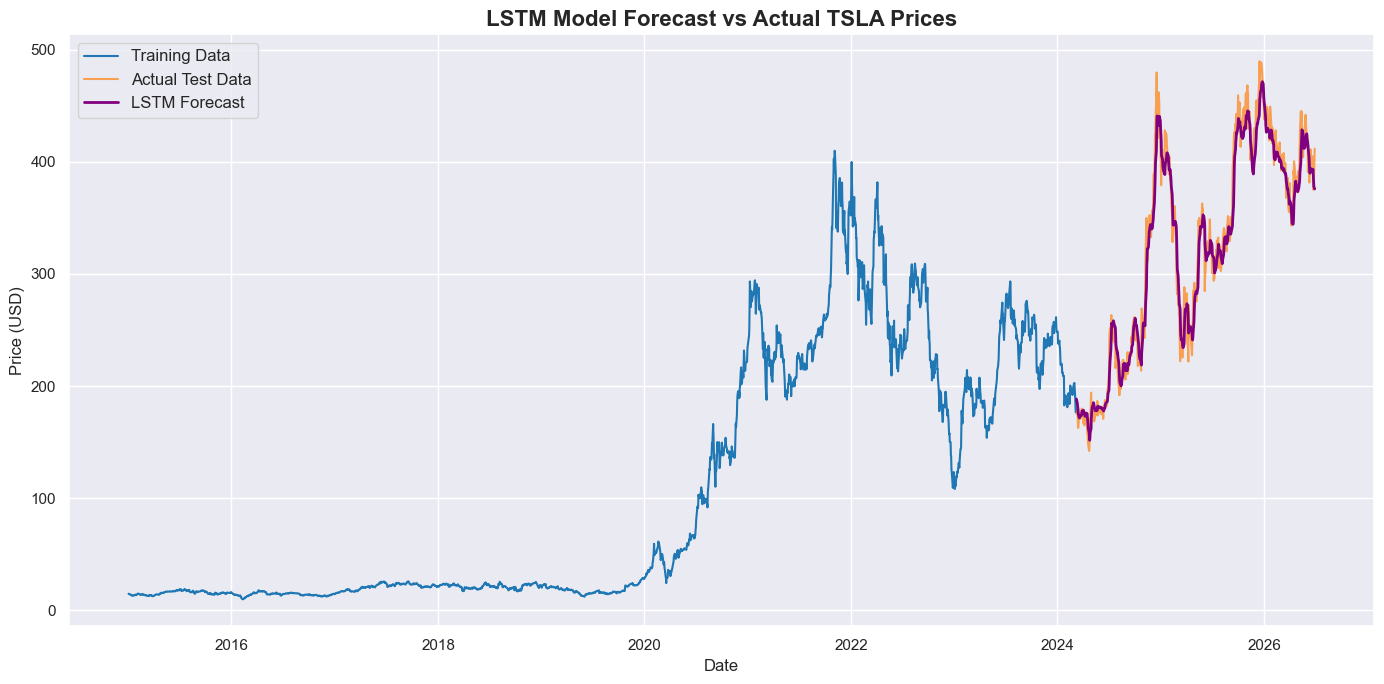

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Uses a smart search algorithm to save time
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title('ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# DEEP LEARNING: LSTM MODELING
# ==========================================
print("\n==== RUNNING LSTM MODEL ====")
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

# 1. Scale Data (Neural Networks are highly sensitive to unscaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
# We reshape to (-1, 1) to convert the pandas series into a 2D array expected by the scaler
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))

# Split the scaled data using the exact same split index as ARIMA
train_scaled = scaled_data[:split_idx]
test_scaled = scaled_data[split_idx:]

# 2. Prepare Sequence Data
window_size = 60 # Use the last 60 days to predict the next 1 day

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)

# Reshape X_train for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# 3. Build LSTM Architecture
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=50, return_sequences=False),
    Dense(units=25),
    Dense(units=1) # Output layer (predicting 1 value)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the Model
print("Training LSTM network (this may take a moment depending on your CPU/GPU)...")
# Epochs=10 and batch_size=32 is a good balance for rapid prototyping
model_lstm.fit(X_train, y_train, batch_size=32, epochs=10, verbose=1)

# 5. Prepare Test Sequence for Forecasting
# To predict the first day of the test set, we need the last 60 days of the training set.
# So we slice the combined scaled_data array accordingly.
inputs = scaled_data[split_idx - window_size:]

X_test = []
for i in range(window_size, len(inputs)):
    X_test.append(inputs[i-window_size:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 6. Generate Forecasts
print("Generating test predictions...")
predicted_prices_scaled = model_lstm.predict(X_test)
# Inverse transform the predictions back to real dollar values
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

# Convert to pandas series for easy plotting
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=test_tsla.index)

# 7. Visualize LSTM Forecast
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Forecast', color='purple', linewidth=2)

plt.title('LSTM Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


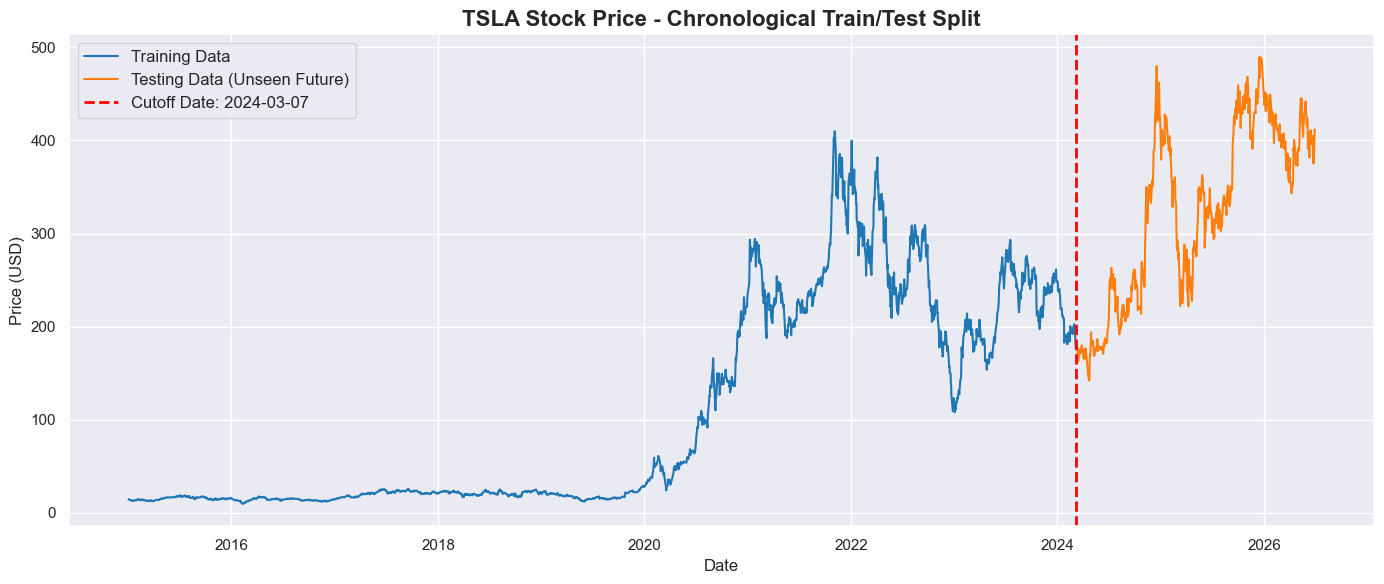


==== ARIMA MODELING: ACF & PACF PLOTS ====


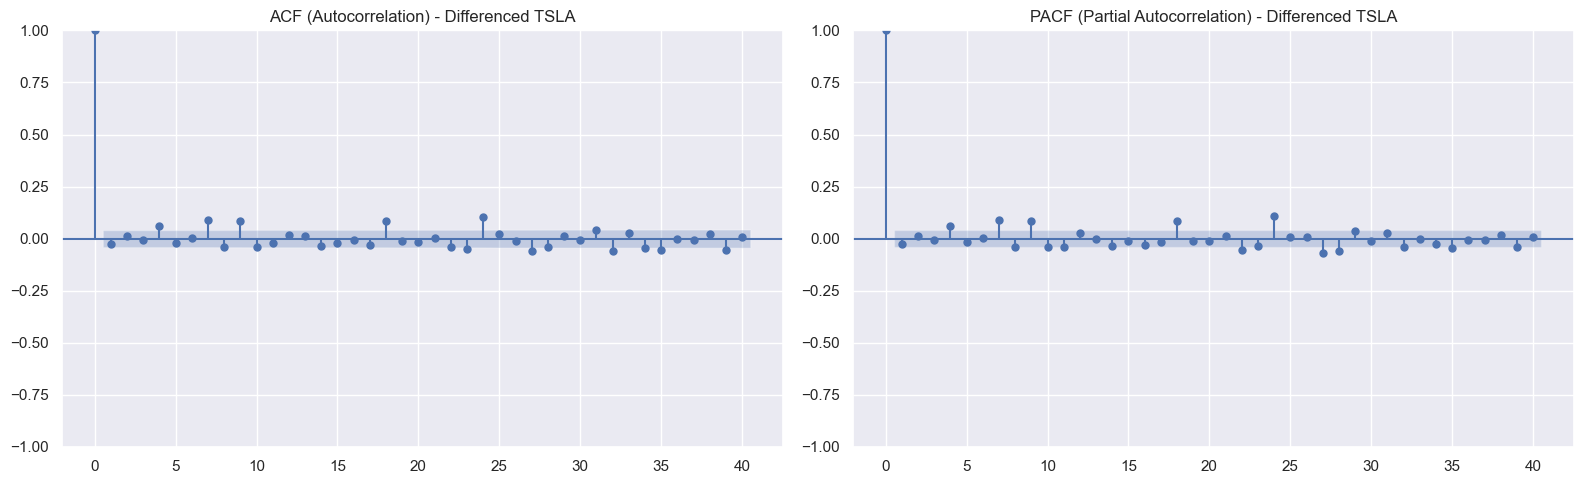


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.42 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.61 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.874 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        00:14:19   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


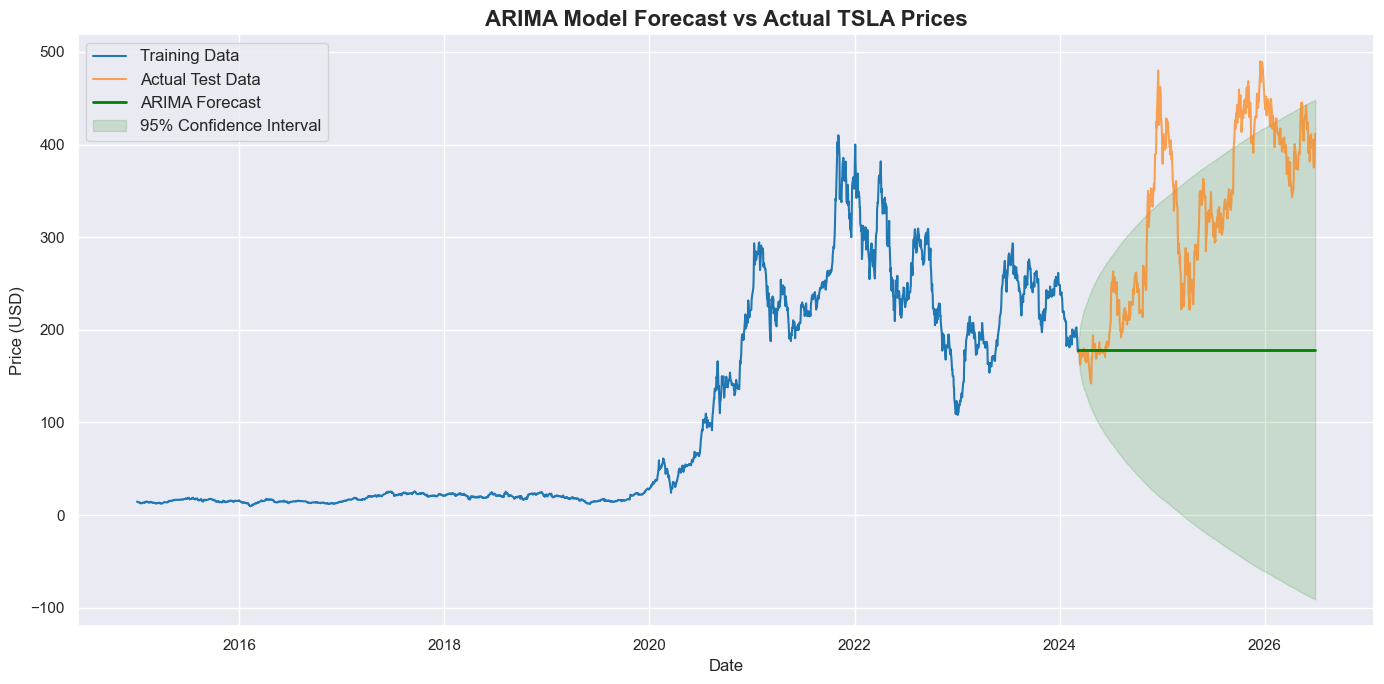


==== RUNNING LSTM MODEL ====
Training optimized LSTM network...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - loss: 0.0199 - val_loss: 0.0023
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0011 - val_loss: 8.6760e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0011 - val_loss: 8.0684e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 9.6401e-04 - val_loss: 0.0016
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.0011 - val_loss: 7.4171e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 8.0143e-04 - val_loss: 6.7316e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/s

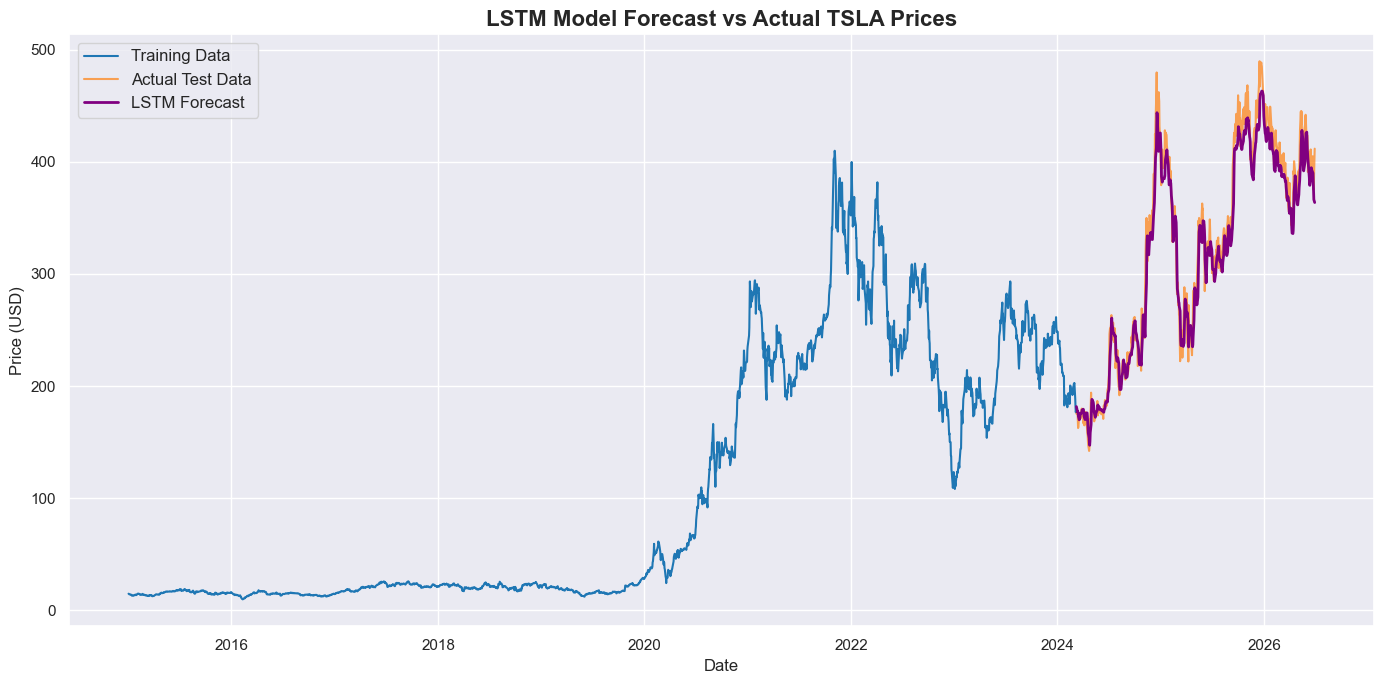

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

# OPTIMIZATION NOTE: stepwise=True uses a smart, fast search algorithm. 
# If you wanted a brute-force Grid Search, you would set stepwise=False.
model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Set to False to perform an exhaustive grid search
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title('ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# DEEP LEARNING: LSTM MODELING
# ==========================================
print("\n==== RUNNING LSTM MODEL ====")
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Scale Data (Neural Networks are highly sensitive to unscaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
# We reshape to (-1, 1) to convert the pandas series into a 2D array expected by the scaler
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))

# Split the scaled data using the exact same split index as ARIMA
train_scaled = scaled_data[:split_idx]
test_scaled = scaled_data[split_idx:]

# 2. Prepare Sequence Data
window_size = 60 # Use the last 60 days to predict the next 1 day

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)

# Reshape X_train for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# 3. Build LSTM Architecture (OPTIMIZED)
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    
    # Layer 1: More neurons (100) and return_sequences=True to pass data to the next LSTM layer
    LSTM(units=100, return_sequences=True),
    Dropout(0.2), # Dropout randomly turns off 20% of neurons to prevent overfitting
    
    # Layer 2: Additional LSTM layer to capture more complex patterns
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Layer 3: Dense layer for final feature extraction
    Dense(units=25),
    
    # Output layer
    Dense(units=1) 
])

# Optimize Hyperparameters: Custom learning rate
custom_optimizer = Adam(learning_rate=0.001)
model_lstm.compile(optimizer=custom_optimizer, loss='mean_squared_error')

# 4. Train the Model
print("Training optimized LSTM network...")
# Experimentation: Increased epochs to 50, changed batch size to 64, added a validation split
model_lstm.fit(X_train, y_train, batch_size=64, epochs=50, validation_split=0.1, verbose=1)

# 5. Prepare Test Sequence for Forecasting
# To predict the first day of the test set, we need the last 60 days of the training set.
# So we slice the combined scaled_data array accordingly.
inputs = scaled_data[split_idx - window_size:]

X_test = []
for i in range(window_size, len(inputs)):
    X_test.append(inputs[i-window_size:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 6. Generate Forecasts
print("Generating test predictions...")
predicted_prices_scaled = model_lstm.predict(X_test)
# Inverse transform the predictions back to real dollar values
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

# Convert to pandas series for easy plotting
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=test_tsla.index)

# 7. Visualize LSTM Forecast
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Forecast', color='purple', linewidth=2)

plt.title('LSTM Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

==== TASK 2: TIME SERIES DATA PREPARATION ====

Successfully loaded data from CSV.

Total Trading Days: 2888
Training Data (80%): 2015-01-02 to 2024-03-07 (2310 days)
Testing Data  (20%): 2024-03-08 to 2026-06-29 (578 days)


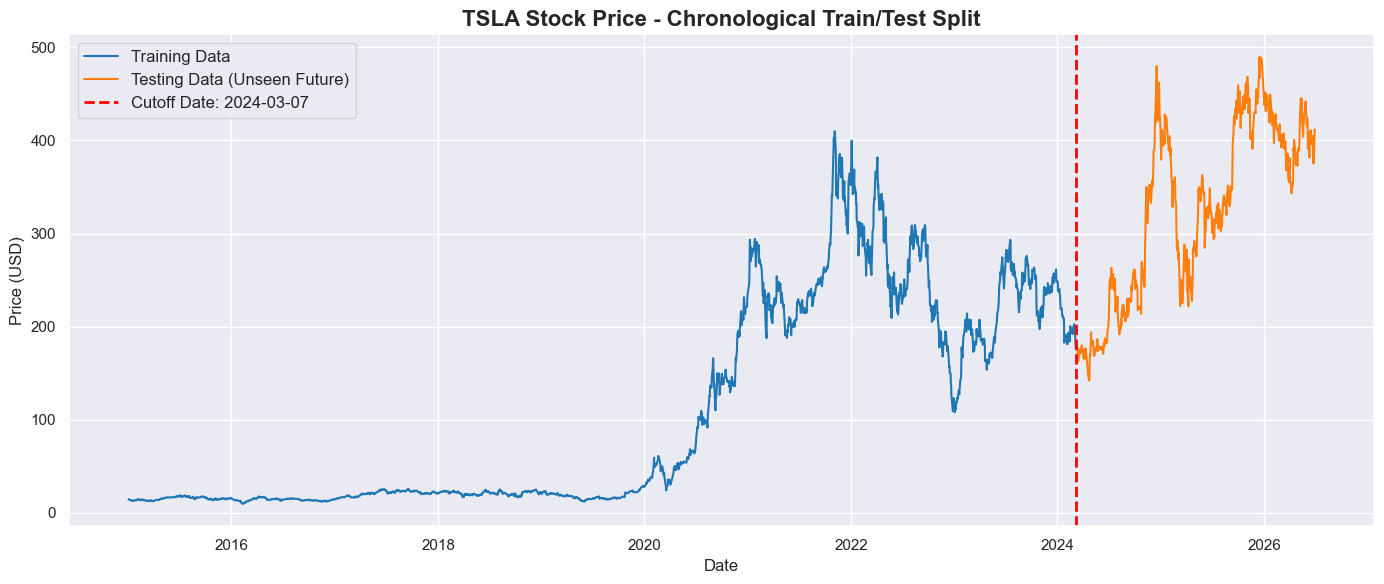


==== ARIMA MODELING: ACF & PACF PLOTS ====


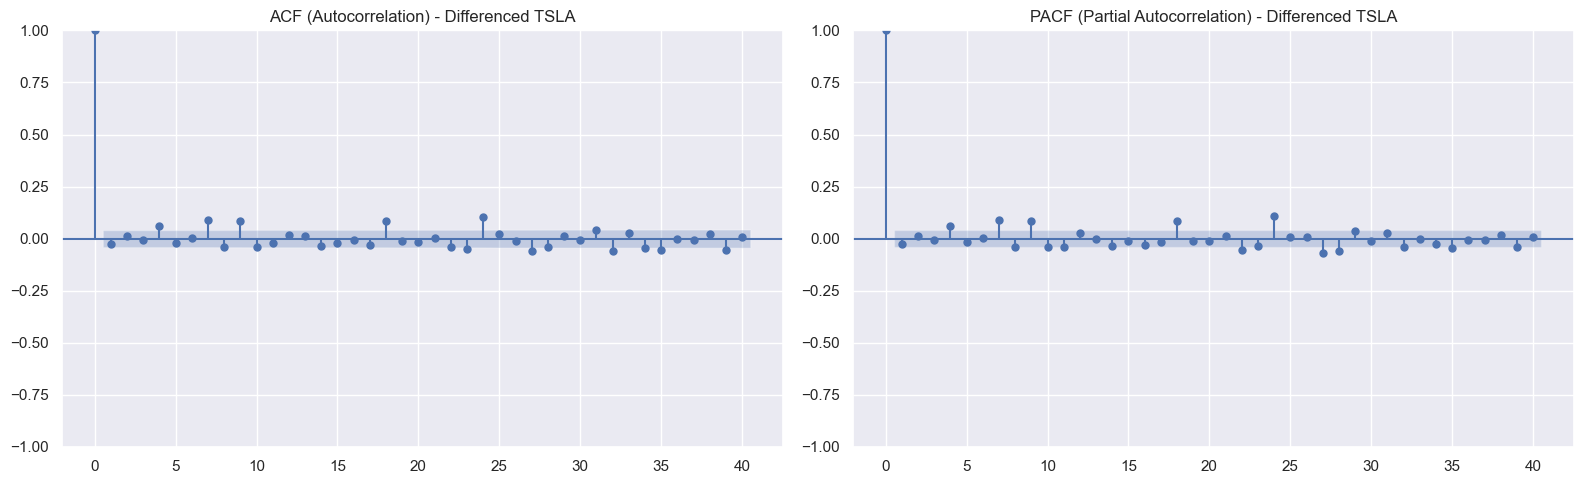


==== RUNNING AUTO ARIMA ====
Searching for the best (p,d,q) parameters based on AIC score...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.33 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.38 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.57 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.25 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=2.26 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.820 seconds

--- Best ARIMA Model Found ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2310
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7303.183
Date:                Wed, 08 Jul 2026   AIC                          14608.366
Time:                        00:25:07   BIC                          14614.110
Sample:                 

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


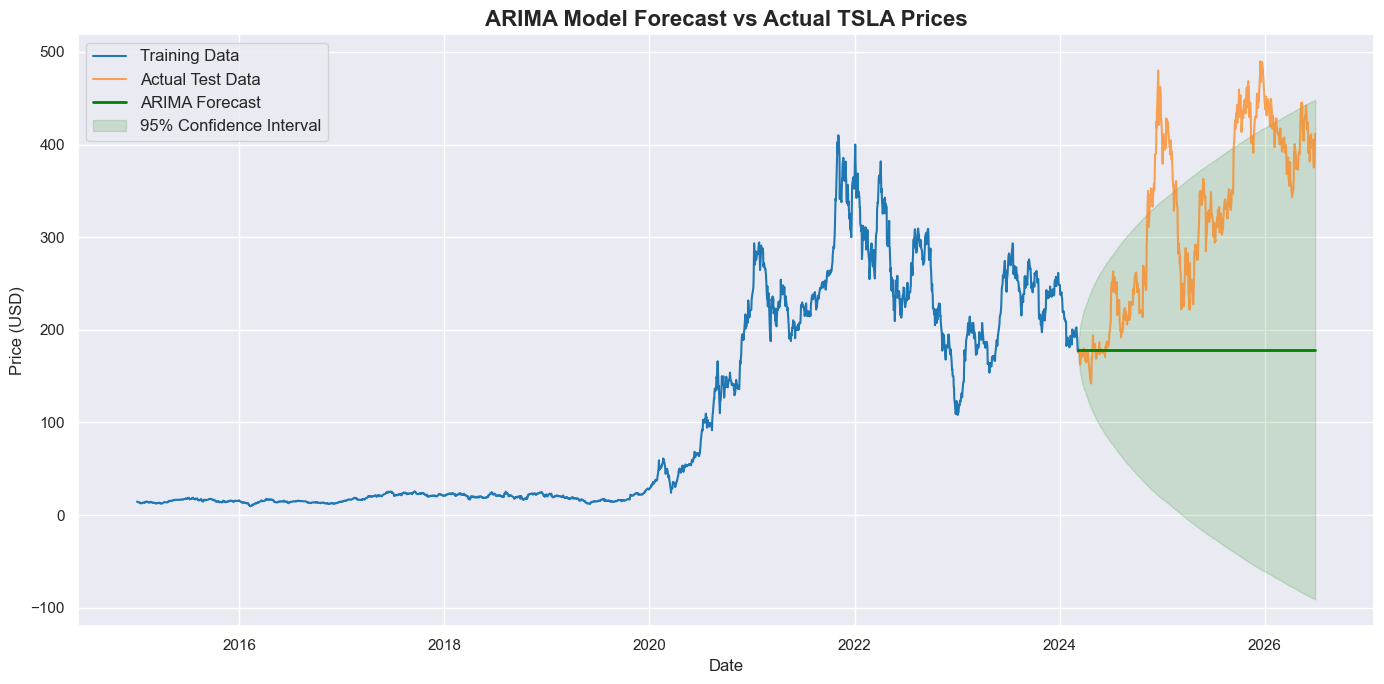


==== RUNNING LSTM MODEL ====
Training optimized LSTM network...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - loss: 0.0161 - val_loss: 0.0014
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0011 - val_loss: 9.5145e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 9.4440e-04 - val_loss: 8.6944e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 0.0011 - val_loss: 9.0792e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - loss: 8.7774e-04 - val_loss: 0.0011
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - loss: 9.5523e-04 - val_loss: 7.5739e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - loss: 8.1227e-04 - val_loss: 8.2581e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━

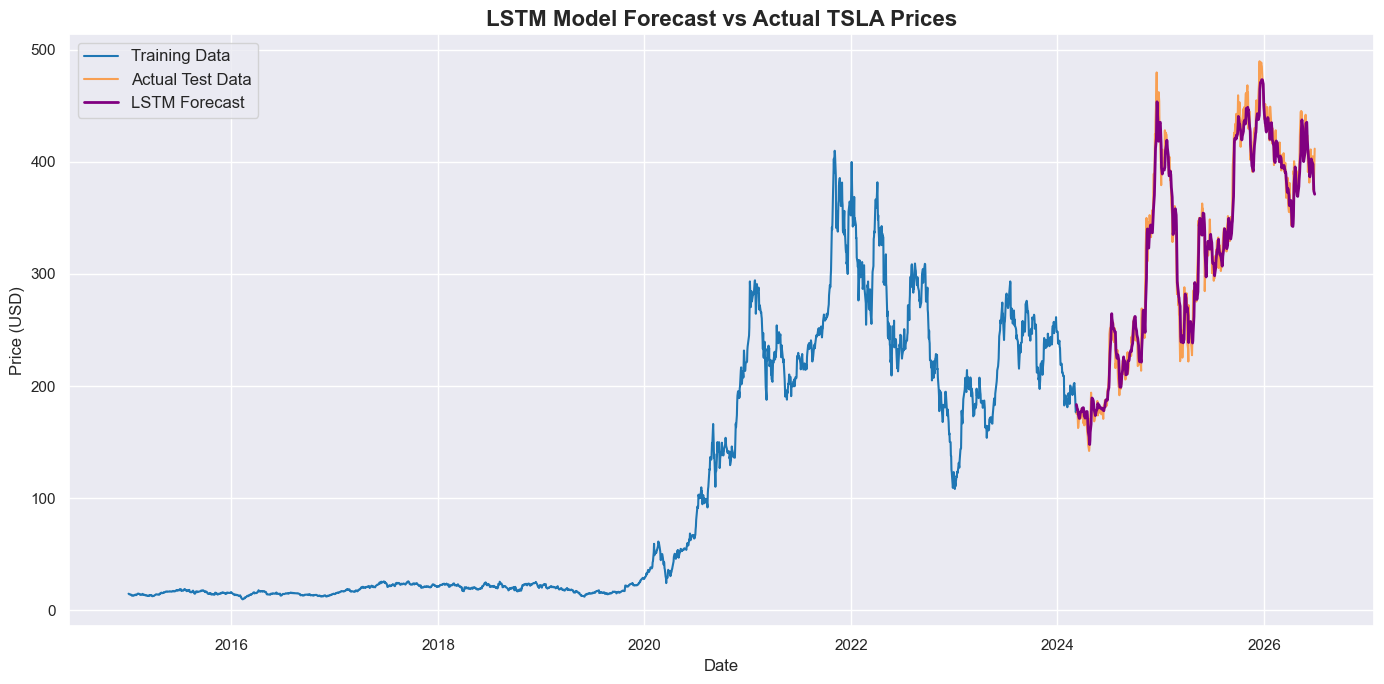


==== MODEL EVALUATION & COMPARISON ====
--- ARIMA Model Performance ---
MAE:  $147.19
RMSE: $173.43
MAPE: 39.96%

--- LSTM Model Performance ---
MAE:  $11.48
RMSE: $15.17
MAPE: 3.69%

--- Final Conclusion ---
Result: The LSTM deep learning model outperformed the ARIMA model, exhibiting a lower Root Mean Squared Error (RMSE).


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import numpy as np

# Set visual style
sns.set_theme(style="darkgrid")

print("==== TASK 2: TIME SERIES DATA PREPARATION ====\n")

# Since we are in a new notebook, we need to reload the data from Task 1.
try:
    # Try to load the CSV we saved earlier in the processed folder
    df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)
    print("Successfully loaded data from CSV.")
    
    # Re-apply the time-based interpolation to handle any missing values
    df_prices_cleaned = df_prices.interpolate(method='time')
    tsla_prices = df_prices_cleaned['TSLA'].squeeze()

except FileNotFoundError:
    # FALLBACK: If the CSV isn't found, fetch ONLY Tesla data to avoid yfinance MultiIndex errors!
    print("CSV not found. Downloading fresh TSLA data from Yahoo Finance...")
    df_prices = yf.download('TSLA', start='2015-01-01', end='2024-12-31')
    
    # Recent yfinance updates sometimes drop 'Adj Close' or change column structures.
    # We will safely use 'Close' if 'Adj Close' is missing.
    if 'Adj Close' in df_prices.columns:
        tsla_prices = df_prices['Adj Close'].interpolate(method='time').squeeze()
    else:
        tsla_prices = df_prices['Close'].interpolate(method='time').squeeze()

# Determine the exact row index for an 80% / 20% split
split_idx = int(len(tsla_prices) * 0.8)

# CRITICAL: Split chronologically using index slicing (no random shuffling!)
train_tsla = tsla_prices.iloc[:split_idx]
test_tsla = tsla_prices.iloc[split_idx:]

# Print the date ranges to verify the chronological split
print(f"\nTotal Trading Days: {len(tsla_prices)}")
print(f"Training Data (80%): {train_tsla.index[0].date()} to {train_tsla.index[-1].date()} ({len(train_tsla)} days)")
print(f"Testing Data  (20%): {test_tsla.index[0].date()} to {test_tsla.index[-1].date()} ({len(test_tsla)} days)")

# ==========================================
# Visualize the Train-Test Split
# ==========================================
plt.figure(figsize=(14, 6))

# Plot training data in blue
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4', linewidth=1.5)

# Plot testing data in orange
plt.plot(test_tsla.index, test_tsla, label='Testing Data (Unseen Future)', color='#ff7f0e', linewidth=1.5)

# Add a vertical dashed line to mark the exact cutoff point
cutoff_date = train_tsla.index[-1]
plt.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2, 
            label=f'Cutoff Date: {cutoff_date.date()}')

plt.title('TSLA Stock Price - Chronological Train/Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# ACF / PACF Plots for Parameter Estimation
# ==========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("\n==== ARIMA MODELING: ACF & PACF PLOTS ====")
# We difference the training data once (d=1) because we proved it was non-stationary in Task 1.
train_diff = train_tsla.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF helps determine the 'q' (Moving Average) term
plot_acf(train_diff, ax=axes[0], lags=40, title='ACF (Autocorrelation) - Differenced TSLA')
# PACF helps determine the 'p' (AutoRegressive) term
plot_pacf(train_diff, ax=axes[1], lags=40, title='PACF (Partial Autocorrelation) - Differenced TSLA')
plt.tight_layout()
plt.show()

# ==========================================
# Auto ARIMA Model (Parameter Search & Fitting)
# ==========================================
from pmdarima import auto_arima

print("\n==== RUNNING AUTO ARIMA ====")
print("Searching for the best (p,d,q) parameters based on AIC score...")
# NOTE ON SARIMA: Daily stock prices rarely exhibit true, predictable seasonality 
# (like retail sales in December). Therefore, we set seasonal=False. 
# If modelling seasonal data, you would use seasonal=True and m=5 (weekly) or m=21 (monthly).

# OPTIMIZATION NOTE: stepwise=True uses a smart, fast search algorithm. 
# If you wanted a brute-force Grid Search, you would set stepwise=False.
model_auto = auto_arima(
    train_tsla, 
    start_p=0, start_q=0, 
    max_p=5, max_q=5, 
    d=1,                      # We know d=1 from our ADF stationarity test
    seasonal=False,           # No strict seasonality in daily stocks
    trace=True,               # Prints out the models it tries
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Set to False to perform an exhaustive grid search
)

print("\n--- Best ARIMA Model Found ---")
print(model_auto.summary())

# ==========================================
# Forecasting the Test Period
# ==========================================
print("\n==== GENERATING FORECASTS ====")
# Predict the exact number of steps into the future as our test dataset length
forecast_steps = len(test_tsla)
# return_conf_int=True gives us the upper and lower bounds of the prediction
forecast, conf_int = model_auto.predict(n_periods=forecast_steps, return_conf_int=True)

# Convert forecast arrays into pandas Series and assign the actual future dates to them
forecast_series = pd.Series(forecast.values, index=test_tsla.index)
lower_bound = pd.Series(conf_int[:, 0], index=test_tsla.index)
upper_bound = pd.Series(conf_int[:, 1], index=test_tsla.index)

# ==========================================
# Visualize the Forecast vs Actual
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', color='green', linewidth=2)

# Fill the confidence interval
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='green', alpha=0.15, label='95% Confidence Interval')

plt.title('ARIMA Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# DEEP LEARNING: LSTM MODELING
# ==========================================
print("\n==== RUNNING LSTM MODEL ====")
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Scale Data (Neural Networks are highly sensitive to unscaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
# We reshape to (-1, 1) to convert the pandas series into a 2D array expected by the scaler
scaled_data = scaler.fit_transform(tsla_prices.values.reshape(-1, 1))

# Split the scaled data using the exact same split index as ARIMA
train_scaled = scaled_data[:split_idx]
test_scaled = scaled_data[split_idx:]

# 2. Prepare Sequence Data
window_size = 60 # Use the last 60 days to predict the next 1 day

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)

# Reshape X_train for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# 3. Build LSTM Architecture (OPTIMIZED)
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    
    # Layer 1: More neurons (100) and return_sequences=True to pass data to the next LSTM layer
    LSTM(units=100, return_sequences=True),
    Dropout(0.2), # Dropout randomly turns off 20% of neurons to prevent overfitting
    
    # Layer 2: Additional LSTM layer to capture more complex patterns
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Layer 3: Dense layer for final feature extraction
    Dense(units=25),
    
    # Output layer
    Dense(units=1) 
])

# Optimize Hyperparameters: Custom learning rate
custom_optimizer = Adam(learning_rate=0.001)
model_lstm.compile(optimizer=custom_optimizer, loss='mean_squared_error')

# 4. Train the Model
print("Training optimized LSTM network...")
# Experimentation: Increased epochs to 50, changed batch size to 64, added a validation split
model_lstm.fit(X_train, y_train, batch_size=64, epochs=50, validation_split=0.1, verbose=1)

# 5. Prepare Test Sequence for Forecasting
# To predict the first day of the test set, we need the last 60 days of the training set.
# So we slice the combined scaled_data array accordingly.
inputs = scaled_data[split_idx - window_size:]

X_test = []
for i in range(window_size, len(inputs)):
    X_test.append(inputs[i-window_size:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 6. Generate Forecasts
print("Generating test predictions...")
predicted_prices_scaled = model_lstm.predict(X_test)
# Inverse transform the predictions back to real dollar values
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

# Convert to pandas series for easy plotting
lstm_forecast_series = pd.Series(predicted_prices[:, 0], index=test_tsla.index)

# 7. Visualize LSTM Forecast
plt.figure(figsize=(14, 7))
plt.plot(train_tsla.index, train_tsla, label='Training Data', color='#1f77b4')
plt.plot(test_tsla.index, test_tsla, label='Actual Test Data', color='#ff7f0e', alpha=0.7)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Forecast', color='purple', linewidth=2)

plt.title('LSTM Model Forecast vs Actual TSLA Prices', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 8. Evaluate and Compare Models (MAE, RMSE, MAPE)
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

print("\n==== MODEL EVALUATION & COMPARISON ====")
# Use the true values from the test set
true_values = test_tsla.values

# Calculate metrics for ARIMA
arima_mae = mean_absolute_error(true_values, forecast_series.values)
arima_rmse = np.sqrt(mean_squared_error(true_values, forecast_series.values))
arima_mape = mean_absolute_percentage_error(true_values, forecast_series.values)

# Calculate metrics for LSTM
lstm_mae = mean_absolute_error(true_values, lstm_forecast_series.values)
lstm_rmse = np.sqrt(mean_squared_error(true_values, lstm_forecast_series.values))
lstm_mape = mean_absolute_percentage_error(true_values, lstm_forecast_series.values)

print("--- ARIMA Model Performance ---")
print(f"MAE:  ${arima_mae:.2f}")
print(f"RMSE: ${arima_rmse:.2f}")
print(f"MAPE: {arima_mape:.2%}")

print("\n--- LSTM Model Performance ---")
print(f"MAE:  ${lstm_mae:.2f}")
print(f"RMSE: ${lstm_rmse:.2f}")
print(f"MAPE: {lstm_mape:.2%}")

print("\n--- Final Conclusion ---")
if lstm_rmse < arima_rmse:
    print("Result: The LSTM deep learning model outperformed the ARIMA model, exhibiting a lower Root Mean Squared Error (RMSE).")
else:
    print("Result: The ARIMA statistical model outperformed the LSTM model, exhibiting a lower Root Mean Squared Error (RMSE).")